# Т-академия, продуктовая аналитика. Итоговый проект

In [34]:
import math

import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
sns.set_style("darkgrid")

# 0. Импорт данных

## 0.1 Описание таблиц

### 0.1.1. Таблица `orders` 


| Поле | Описание |
|------|----------|
| order_id | Уникальный идентификатор заказа |
| session_id | Идентификатор пользовательской сессии, в рамках которой был оформлен заказ |
| client_id | Уникальный идентификатор клиента |
| address_id | Идентификатор адреса доставки |
| store_id | Идентификатор магазина |
| city | Город клиента |
| platform | Платформа клиента (iOS, Android, Web) |
| order_created_at | Дата и время оформления заказа |
| order_date | Дата заказа |
| delivery_slot_start | Начало выбранного интервала доставки |
| items_count | Количество товаров в заказе |
| gross_merchandise_value | Стоимость товаров до применения скидок |
| discount_type | Тип примененной скидки |
| discount_amount | Размер скидки |
| delivery_fee | Стоимость доставки |
| service_fee | Размер сервисного сбора |
| paid_amount | Итоговая сумма оплаты клиентом |
| payment_method | Способ оплаты |
| campaign_id | Идентификатор маркетинговой кампании, связанной с заказом |
| experiment_group | Экспериментальная группа клиента (test/control/no_campaign) |
| is_marketing_touched | Признак того, что заказ связан с маркетинговой коммуникацией |

### 0.1.2. Таблица `funnel` 


В рамках сессии пользователь может пройти следующие этапы: **поиск товара** -> **просмотр карточки товара** -> **добавление в корзину** -> **переход в корзину** -> **покупка**:
| Поле | Описание |
|------|----------|
| session_id | Уникальный идентификатор сессии |
| client_id | Идентификатор клиента |
| address_id | Идентификатор адреса |
| session_start_at | Дата и время начала сессии |
| session_date | Дата сессии |
| city | Город клиента |
| platform | Платформа клиента |
| traffic_source | Источник трафика |
| campaign_id | Идентификатор маркетинговой кампании |
| experiment_group | Экспериментальная группа |
| timing_period | Период отправки коммуникации |
| service_visit | Флаг захода в сервис |
| product_search | Флаг выполнения поиска товара |
| product_card_view | Флаг просмотра карточки товара |
| add_to_cart | Флаг добавления товара в корзину |
| cart_visit | Флаг перехода в корзину |
| purchase | Флаг покупки |
| order_id | Идентификатор заказа, если покупка состоялась |
| search_at | Время выполнения поиска |
| product_card_view_at | Время просмотра карточки товара |
| add_to_cart_at | Время добавления товара в корзину |
| cart_visit_at | Время перехода в корзину |
| purchase_at | Время покупки |


### 0.1.3. Таблица `marketing communications`


| Поле | Описание |
|------|----------|
| communication_id | Уникальный идентификатор коммуникации |
| campaign_id | Идентификатор маркетинговой кампании |
| communication_type | Тип коммуникации |
| client_id | Идентификатор клиента |
| send_datetime | Дата и время отправки |
| send_date | Дата отправки |
| send_hour | Час отправки |
| timing_period | Категория времени отправки коммуникации |
| experiment_group | Экспериментальная группа (test/control) |
| send_status | Статус коммуникации |


## 0.2 Импорт таблиц

In [36]:
orders = pd.read_csv("datasets/grocery_delivery_orders_2025_11_2026_04.csv")
funnel = pd.read_csv("datasets/grocery_delivery_funnel_2025_11_2026_04.csv")
communications = pd.read_csv("datasets/grocery_delivery_marketing_communications_2025_11_2026_04.csv")

# 1. EDA

## 1.1 Проверка корректности данных

In [37]:
orders.head()

,order_id,session_id,client_id,address_id,store_id,city,platform,order_created_at,order_date,delivery_slot_start,...,gross_merchandise_value,discount_type,discount_amount,delivery_fee,service_fee,paid_amount,payment_method,campaign_id,experiment_group,is_marketing_touched
0,O000000112,SESS000000651,C008041,A0011675,S031,Новосибирск,ios,2025-11-01 09:00:00,2025-11-01,2025-11-01 18:00:00,...,2620.76,none,0.0,0,39.31,2660.07,cash,NaN,no_campaign,0
1,O000000026,SESS000000148,C002410,A0002250,S067,Москва,ios,2025-11-01 09:18:00,2025-11-01,2025-11-01 11:00:00,...,4767.18,none,0.0,99,71.51,4937.69,card,NaN,no_campaign,0
2,O000000169,SESS000000872,C006795,A0006500,S011,Москва,ios,2025-11-01 09:19:11,2025-11-01,2025-11-01 19:00:00,...,3112.03,none,0.0,99,0.00,3211.03,card,NaN,no_campaign,0
3,O000000072,SESS000000433,C008460,A0010616,S057,Москва,web,2025-11-01 09:27:00,2025-11-01,2025-11-01 20:00:00,...,3380.14,none,0.0,99,50.70,3529.84,card,NaN,no_campaign,0
4,O000000008,SESS000000058,C008434,A0001936,S026,Екатеринбург,ios,2025-11-01 09:31:13,2025-11-01,2025-11-01 22:00:00,...,3501.61,fixed_amount,200.0,99,0.00,3400.61,card,NaN,no_campaign,0


In [38]:
funnel.head()

,session_id,client_id,address_id,session_start_at,session_date,city,platform,traffic_source,campaign_id,experiment_group,...,product_card_view,add_to_cart,cart_visit,purchase,order_id,search_at,product_card_view_at,add_to_cart_at,cart_visit_at,purchase_at
0,SESS000000514,C003975,A0000378,2025-11-01 08:04:53,2025-11-01,Москва,android,direct,NaN,no_campaign,...,1,0,0,0,NaN,2025-11-01 08:07:53,2025-11-01 08:07:53,NaN,NaN,NaN
1,SESS000000286,C000830,A0011473,2025-11-01 08:11:12,2025-11-01,Москва,android,organic,NaN,no_campaign,...,1,1,0,0,NaN,2025-11-01 08:12:12,2025-11-01 08:16:12,2025-11-01 08:23:12,NaN,NaN
2,SESS000000248,C005196,A0005849,2025-11-01 08:11:57,2025-11-01,Казань,ios,organic,NaN,no_campaign,...,1,1,1,0,NaN,2025-11-01 08:15:57,2025-11-01 08:21:57,2025-11-01 08:21:57,2025-11-01 08:31:57,NaN
3,SESS000000387,C007786,A0001717,2025-11-01 08:16:26,2025-11-01,Москва,android,direct,NaN,no_campaign,...,1,0,0,0,NaN,2025-11-01 08:18:26,2025-11-01 08:24:26,NaN,NaN,NaN
4,SESS000000197,C001541,A0001204,2025-11-01 08:21:22,2025-11-01,Санкт-Петербург,web,crm,CMP0001,test,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
communications.head()

,communication_id,campaign_id,communication_type,client_id,send_datetime,send_date,send_hour,timing_period,experiment_group,send_status
0,COM00000001,CMP0001,email,C000437,2025-11-01 18:15:00,2025-11-01,18,evening,control,holdout_control
1,COM00000002,CMP0001,email,C004047,2025-11-01 18:15:00,2025-11-01,18,evening,control,holdout_control
2,COM00000003,CMP0001,email,C003127,2025-11-01 18:15:00,2025-11-01,18,evening,test,sent
3,COM00000004,CMP0001,email,C005987,2025-11-01 18:15:00,2025-11-01,18,evening,test,sent
4,COM00000005,CMP0001,email,C002831,2025-11-01 18:15:00,2025-11-01,18,evening,test,sent


Для начала посмотрим на размеры таблиц и на то, правильные ли типы данных у каждого столбца и есть ли пропуски:

In [40]:
orders.shape, funnel.shape, communications.shape

((21884, 21), (144710, 23), (72193, 10))

In [41]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21884 entries, 0 to 21883
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_id                 21884 non-null  object 
 1   session_id               21884 non-null  object 
 2   client_id                21884 non-null  object 
 3   address_id               21884 non-null  object 
 4   store_id                 21884 non-null  object 
 5   city                     21884 non-null  object 
 6   platform                 21884 non-null  object 
 7   order_created_at         21884 non-null  object 
 8   order_date               21884 non-null  object 
 9   delivery_slot_start      21884 non-null  object 
 10  items_count              21884 non-null  int64  
 11  gross_merchandise_value  21884 non-null  float64
 12  discount_type            21884 non-null  object 
 13  discount_amount          21884 non-null  float64
 14  delivery_fee          

In [42]:
funnel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144710 entries, 0 to 144709
Data columns (total 23 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   session_id            144710 non-null  object
 1   client_id             144710 non-null  object
 2   address_id            144710 non-null  object
 3   session_start_at      144710 non-null  object
 4   session_date          144710 non-null  object
 5   city                  144710 non-null  object
 6   platform              144710 non-null  object
 7   traffic_source        144710 non-null  object
 8   campaign_id           6699 non-null    object
 9   experiment_group      144710 non-null  object
 10  timing_period         144710 non-null  object
 11  service_visit         144710 non-null  int64 
 12  product_search        144710 non-null  int64 
 13  product_card_view     144710 non-null  int64 
 14  add_to_cart           144710 non-null  int64 
 15  cart_visit       

In [43]:
communications.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72193 entries, 0 to 72192
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   communication_id    72193 non-null  object
 1   campaign_id         72193 non-null  object
 2   communication_type  72193 non-null  object
 3   client_id           72193 non-null  object
 4   send_datetime       72193 non-null  object
 5   send_date           72193 non-null  object
 6   send_hour           72193 non-null  int64 
 7   timing_period       72193 non-null  object
 8   experiment_group    72193 non-null  object
 9   send_status         72193 non-null  object
dtypes: int64(1), object(9)
memory usage: 5.5+ MB


В таблице `orders` есть поле campaign_id, которое имеет много пропусков. Это логично, ведь некоторые заказы могут не быть привязаны к какой-либо маркетинговой кампании. Есть некоторые столбцы, которые нужно конвертировать в datetime

В таблице `funnel` есть несколько полей с null значениями: уже описанный выше campaign_id, а также времена попадания в определенную часть воронки. Эти пропуски аналогично имеют место и их не нужно заполнять. Некоторые столбцы нужно конвертировать в  datetime

В таблице `communications` пропусков нет. Некоторые столбцы нужно конвертировать в  datetime

In [44]:
# Конвертация дат в datetime формат 
datetime_columns = {
    "orders": ["order_created_at", "order_date", "delivery_slot_start"], 
    "funnel": ["session_start_at", "session_date", "search_at", "product_card_view_at", "add_to_cart_at", "cart_visit_at", "purchase_at"],
    "communications": ["send_date", "send_datetime"]
}

for table, table_name in zip((orders, funnel, communications), 
                             ("orders", "funnel", "communications")):
    columns = datetime_columns[table_name]
    table[columns] = table[columns].apply(pd.to_datetime)


Далее посмотрим на статистику по числовым и временным полям:

In [45]:
orders.describe()

,order_created_at,order_date,delivery_slot_start,items_count,gross_merchandise_value,discount_amount,delivery_fee,service_fee,paid_amount,is_marketing_touched
count,21884,21884,21884,21884.000000,21884.000000,21884.000000,21884.000000,21884.000000,21884.000000,21884.000000
mean,2026-01-29 00:38:56.904907520,2026-01-28 07:41:08.214220544,2026-01-28 23:40:54.066898432,9.754250,2822.223200,49.196609,104.753838,35.940552,2913.720966,0.047797
min,2025-11-01 09:00:00,2025-11-01 00:00:00,2025-11-01 10:00:00,1.000000,550.000000,0.000000,0.000000,0.000000,456.080000,0.000000
25%,2025-12-15 19:25:17.249999872,2025-12-15 00:00:00,2025-12-15 19:00:00,7.000000,2066.570000,0.000000,99.000000,10.810000,2144.270000,0.000000
50%,2026-01-28 23:02:34,2026-01-28 00:00:00,2026-01-28 22:00:00,10.000000,2683.220000,0.000000,99.000000,37.770000,2771.580000,0.000000
75%,2026-03-13 19:42:05.750000128,2026-03-13 00:00:00,2026-03-13 19:00:00,12.000000,3429.850000,0.000000,149.000000,53.250000,3534.017500,0.000000
max,2026-04-30 23:45:19,2026-04-30 00:00:00,2026-04-30 22:00:00,26.000000,9046.220000,882.710000,199.000000,157.520000,9195.220000,1.000000
std,NaN,NaN,NaN,3.286488,1049.980977,108.654131,66.524086,26.608279,1062.026662,0.213342


In [46]:
funnel.describe()

,session_start_at,session_date,service_visit,product_search,product_card_view,add_to_cart,cart_visit,purchase,search_at,product_card_view_at,add_to_cart_at,cart_visit_at,purchase_at
count,144710,144710,144710.0,144710.000000,144710.000000,144710.000000,144710.000000,144710.000000,104124,86761,44978,35223,21884
mean,2026-01-30 05:44:54.518008576,2026-01-29 13:11:55.522078464,1.0,0.719536,0.599551,0.310815,0.243404,0.151227,2026-01-30 03:36:08.781827328,2026-01-30 03:28:58.497319936,2026-01-28 17:47:19.710947584,2026-01-28 20:38:24.868750848,2026-01-29 00:38:25.928851968
min,2025-11-01 08:04:53,2025-11-01 00:00:00,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,2025-11-01 08:07:53,2025-11-01 08:07:53,2025-11-01 08:21:57,2025-11-01 08:31:57,2025-11-01 08:55:00
25%,2025-12-15 19:21:42.249999872,2025-12-15 00:00:00,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,2025-12-15 21:25:26.249999872,2025-12-15 23:32:42,2025-12-15 08:16:42.500000,2025-12-15 13:03:26,2025-12-15 19:19:36
50%,2026-01-30 14:37:29,2026-01-30 00:00:00,1.0,1.000000,1.000000,0.000000,0.000000,0.000000,2026-01-30 11:36:35.500000,2026-01-30 11:11:08,2026-01-28 18:44:05,2026-01-28 19:36:27,2026-01-28 23:08:15.500000
75%,2026-03-15 22:52:33.750000128,2026-03-15 00:00:00,1.0,1.000000,1.000000,1.000000,0.000000,0.000000,2026-03-15 19:40:18,2026-03-15 18:46:13,2026-03-13 16:02:06.500000,2026-03-13 18:28:42,2026-03-13 19:50:16
max,2026-04-30 23:55:31,2026-04-30 00:00:00,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,2026-04-30 23:58:26,2026-04-30 23:58:31,2026-04-30 23:42:25,2026-04-30 23:34:35,2026-04-30 23:46:19
std,NaN,NaN,0.0,0.449228,0.489991,0.462829,0.429138,0.358271,NaN,NaN,NaN,NaN,NaN


In [47]:
communications.describe()

,send_datetime,send_date,send_hour
count,72193,72193,72193.000000
mean,2026-01-30 20:07:07.042788096,2026-01-30 03:05:58.887981056,16.620143
min,2025-11-01 18:15:00,2025-11-01 00:00:00,6.000000
25%,2025-12-16 20:45:00,2025-12-16 00:00:00,17.000000
50%,2026-01-30 19:30:00,2026-01-30 00:00:00,18.000000
75%,2026-03-16 18:45:00,2026-03-16 00:00:00,19.000000
max,2026-04-30 07:30:00,2026-04-30 00:00:00,20.000000
std,NaN,NaN,4.338967


Действительно, в таблицах содержатся данные по заказам за 6 месяцев: с 01.11.2025 по 30.04.2026. Но возможна ситуация, что данные в конце периода собраны частично. Нужно удостовериться, что количество сессий не проседает в конце периода

Отрицательных значений в числовых полях нет, аномальных диапазонов не обнаружено.

Также узнали следующие вещи: 
1. Максимально в одном заказе было 26 предметов
2. Максимальный GMV за заказ - 9046.22
3. ~4.8% заказов были как-то связаны с маркетингом (is_marketing_touched == 1)
4. Только ~15.1% от числа всех сессий в сервисе в конечном итоге окончились покупкой
5. рассылка коммуникаций осуществлялась с 6 до 20 

Для каждой таблицы есть уникальные идентификаторы: 
1. `orders`: order_id, session_id
2. `funnel`: session_id 
3. `communications`: communication_id

Проверим, что идентификаторы действительно уникальны: 

In [48]:
for table, id_column in zip((orders, orders, funnel, communications),
                            ("order_id", "session_id", "session_id", "communication_id")):
    print(table.shape[0] == table[id_column].nunique())

True
True
True
True


Идентификаторы действительно уникальны.

Далее проверим следующее: 
1. Все сессии из `funnel`, которые в итоге окончились покупкой, действительно имеют записи в таблице `orders`
2. Все заказы из таблицы `orders` имеют описание сессии в таблице `funnel`

In [49]:
purchase_sessions = funnel[funnel["purchase"] == 1].copy()

# сравним количество сессионных индексов успешных покупок, которые есть в таблице orders, с общим количеством успешных покупок
print(purchase_sessions.session_id.isin(orders.session_id).sum() == purchase_sessions.shape[0])

# сравним количество заказов с количеством успешных заказов в сессиях, соответствующих этим заказам
print(orders.session_id.isin(purchase_sessions.session_id).sum() == orders.shape[0])

True
True


заказ из таблицы `orders` всегда имеет описание сессии в таблице `funnel`. Аналогично, все сессии, закончившиеся покупкой, имеют детализацию покупки

Удостоверимся теперь, что количество сессий не проседает к концу периода: 

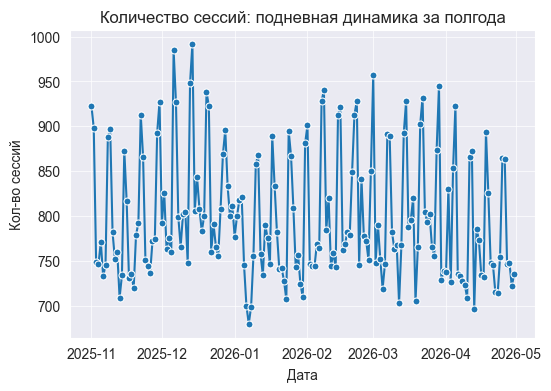

In [50]:
plt.figure(figsize=(6, 4))

sns.lineplot(funnel.groupby("session_date").size(), marker="o", markersize=5)
plt.xlabel("Дата")
plt.ylabel("Кол-во сессий")
plt.title("Количество сессий: подневная динамика за полгода")
plt.grid(alpha=0.7)

plt.show()

Нет сильных просадок, что позволяет говорить о том, что, вероятнее всего, в конце периода данные были собраны полностью. Также по графику можем заметить ярко выраженную недельную сезонность. Уже на данном этапе можно предполагать о том, что будние дни и выходные будут сильно отличаться по метрике GMV. Учтем это предположение для анализа по срезам во втором разделе

Важно заметить, что причиной падения GMV могут быть большие или, наоборот, маленькие скидки. Для того, чтобы это проверить на этапе исследования причин, нужно удостовериться, что данные собраны корректно и все сходится. Иными словами, удостоверимся, что GMV раскладывается следующим образом: 

$$
GMV = paid\_amount - service\_fee - delivery\_fee + discount\_amount
$$


In [51]:
(
    orders["gross_merchandise_value"] - 
    (orders["paid_amount"] - orders["service_fee"] - orders["delivery_fee"] + orders["discount_amount"]) < 0.05  # учитываем от погрешности
).mean()

np.float64(1.0)

Действительно, 100% наблюдений подчиняются такой логике. Формулу можно использовать

## 1.2 Анализ метрики GMV

Посмотрим, насколько шумна метрика GMV:

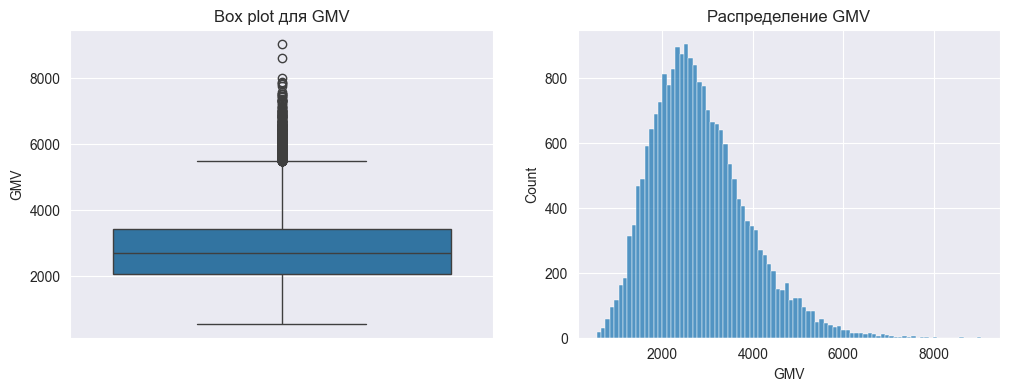

In [52]:
gmv = orders.gross_merchandise_value

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(gmv, ax=ax1)
ax1.set_title("Box plot для GMV")
ax1.set_ylabel("GMV")
sns.histplot(gmv, ax=ax2)
ax2.set_xlabel("GMV")
ax2.set_title("Распределение GMV")

plt.show() 

In [53]:
Q1 = gmv.quantile(0.25)
Q3 = gmv.quantile(0.75)

upper_bound = Q3 + 1.5 * (Q3 - Q1)
print(f"Общее количество заказов: {gmv.size}")
print(f"Количество выбросов по правилу межквартильных размахов: {(gmv > upper_bound).sum()}. Доля: {(gmv > upper_bound).sum() / gmv.size}")

Общее количество заказов: 21884
Количество выбросов по правилу межквартильных размахов: 386. Доля: 0.01763845732041674


~1.7% заказов имеют очень высокий gmv (> ~6000). Посмотрим динамику возникновения выбросов GMV по месяцам

In [54]:
def normalize(series):
    return series / series.iloc[0] * 100

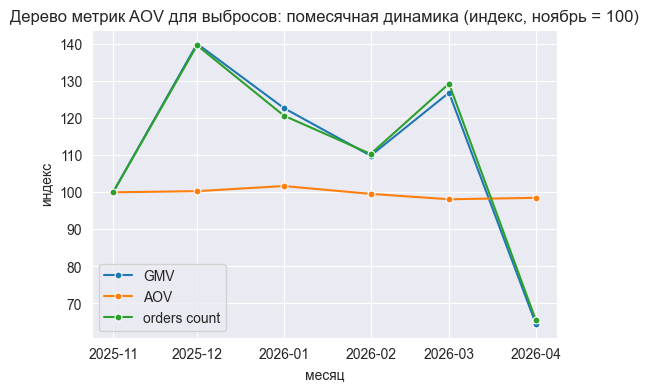

In [55]:
orders.loc[:, "order_month"] = orders["order_date"].dt.to_period("M").dt.to_timestamp()

outliers = orders[orders["gross_merchandise_value"] > upper_bound].copy()
outliers.loc[:, "order_month"] = outliers["order_date"].dt.to_period("M").dt.to_timestamp()

plt.figure(figsize=(6, 4))

sns.lineplot(normalize(outliers.groupby("order_month").gross_merchandise_value.sum()), marker="o", markersize=5, label="GMV")
sns.lineplot(normalize(outliers.groupby("order_month").gross_merchandise_value.mean()), marker="o", markersize=5, label="AOV")
sns.lineplot(normalize(outliers.groupby("order_month").size()), marker="o", markersize=5, label="orders count")

plt.title("Дерево метрик AOV для выбросов: помесячная динамика (индекс, ноябрь = 100)")
plt.ylabel("индекс")
plt.xlabel("месяц")

plt.show()

Видим, что заказов с высоким GMV в последний месяц стало намного меньше, а AOV дорогих заказов почти не изменился. Посмотрим, соотносится ли эта картина с общей динамикой по всем заказам: 

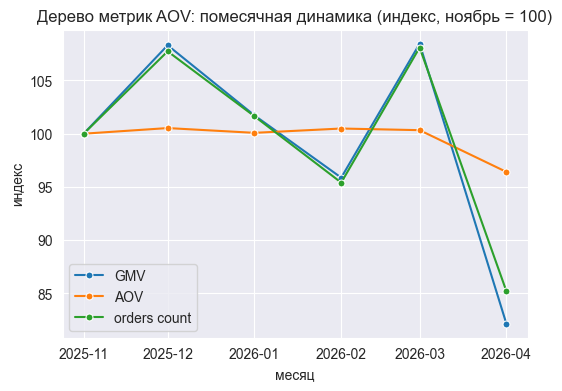

In [56]:
plt.figure(figsize=(6, 4))

sns.lineplot(normalize(orders.groupby("order_month").gross_merchandise_value.sum()), marker="o", markersize=5, label="GMV")
sns.lineplot(normalize(orders.groupby("order_month").gross_merchandise_value.mean()), marker="o", markersize=5, label="AOV")
sns.lineplot(normalize(orders.groupby("order_month").size()), marker="o", markersize=5, label="orders count")

plt.title("Дерево метрик AOV: помесячная динамика (индекс, ноябрь = 100)")
plt.ylabel("индекс")
plt.xlabel("месяц")

plt.show()

Общая динамика почти аналогична динамике выбросов. Значит, падение системное, а не за счёт ухода крупных клиентов - далее отдельно выбросы больше не рассматриваются

# 2. Исследование причин падения оборота

В конце предыдущего пункта была выяснена главная проблема падения GMV: 
- **Падение общего количества заказов**

Количество заказов раскладывается как произведение количества покупателей на среднее количество покупок. Построим графики каждой из этих метрик:

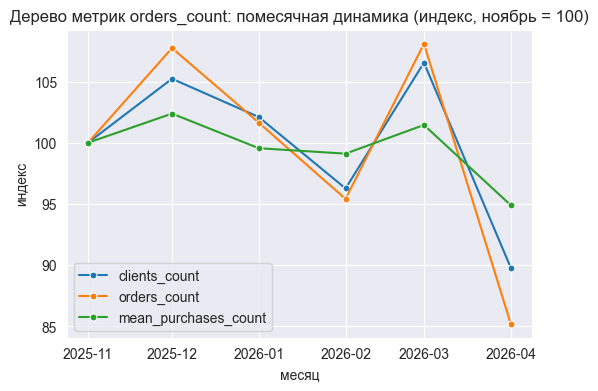

In [57]:
purchase_sessions = purchase_sessions.merge(orders[["session_id", "order_month"]], on="session_id")  # получение столбца order_date для сессий

stat = purchase_sessions.groupby("order_month").agg(
    clients_count = ("client_id", "nunique"), 
    orders_count = ("order_id", "nunique")
)
stat["mean_purchases_count"] = stat["orders_count"] / stat["clients_count"]

plt.figure(figsize=(6, 4))

for series_name, series in stat.items():
    sns.lineplot(normalize(series), marker="o", markersize=5, label=series_name)

plt.title("Дерево метрик orders_count: помесячная динамика (индекс, ноябрь = 100)")
plt.ylabel("индекс")
plt.xlabel("месяц")

plt.show()

Из графика видно, что количество заказов сильно соотносится с количеством покупателей. Нужно исследовать падение количества покупателей. Разложим: 
$$\text{clients\_count} = \text{MAU} \cdot \text{CR}_\text{purchase}$$

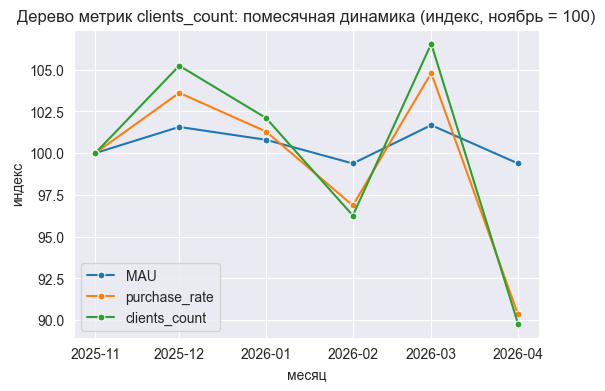

In [58]:
funnel["session_month"] = funnel["session_date"].dt.to_period("M").dt.to_timestamp()

stat = funnel.groupby("session_month").agg(
    MAU = ("client_id", "nunique"),
    # purchase_rate = ("purchase", "mean")
)
stat["purchase_rate"] = orders.groupby("order_month").client_id.nunique() / stat["MAU"]
stat["clients_count"] = purchase_sessions.groupby("order_month").client_id.nunique()

plt.figure(figsize=(6, 4))

for series_name, series in stat.items():
    sns.lineplot(normalize(series), marker="o", markersize=5, label=series_name)

plt.title("Дерево метрик clients_count: помесячная динамика (индекс, ноябрь = 100)")
plt.ylabel("индекс")
plt.xlabel("месяц")

plt.show()

Количество пользователей упало в рамках погрешности (примерно такое же значение, как 2 месяца назад). Просадка вызвана падением конверсии пользователя в покупателя. Посмотрим, на каком этапе воронки происходит проблема:

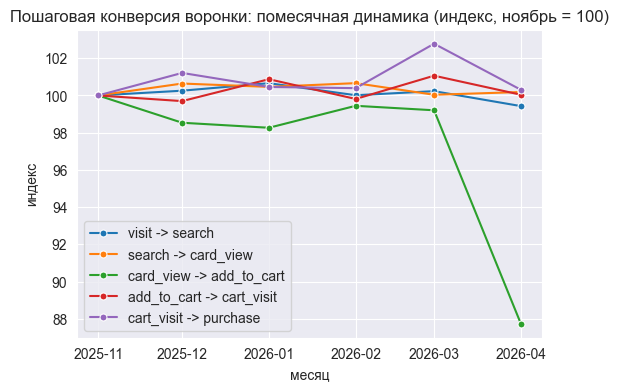

In [59]:
funnel_steps = [
    "service_visit",
    "product_search",
    "product_card_view",
    "add_to_cart",
    "cart_visit",
    "purchase",
]

reach = funnel.groupby("session_month")[funnel_steps].mean()

# построение пошаговой конверсии
step_cr = reach.copy()
for i in range(len(funnel_steps) - 1, 0, -1):
    step_cr[funnel_steps[i]] = reach[funnel_steps[i]] / reach[funnel_steps[i - 1]]
step_cr = step_cr.drop(columns="service_visit") 

step_cr.columns = [
    "visit -> search",
    "search -> card_view",
    "card_view -> add_to_cart",
    "add_to_cart -> cart_visit",
    "cart_visit -> purchase",
]

plt.figure(figsize=(6, 4))
for col in step_cr.columns:
    sns.lineplot(normalize(step_cr[col]), marker="o", markersize=5, label=col)
    
plt.title("Пошаговая конверсия воронки: помесячная динамика (индекс, ноябрь = 100)")
plt.ylabel("индекс")
plt.xlabel("месяц")
plt.legend(loc="lower left")

plt.show()

Пользователи начали чаще отваливаться на этапе добавления товаров в корзину. Построим этот же график в подневном масштабе, чтобы определить, насколько быстро произошел слом:

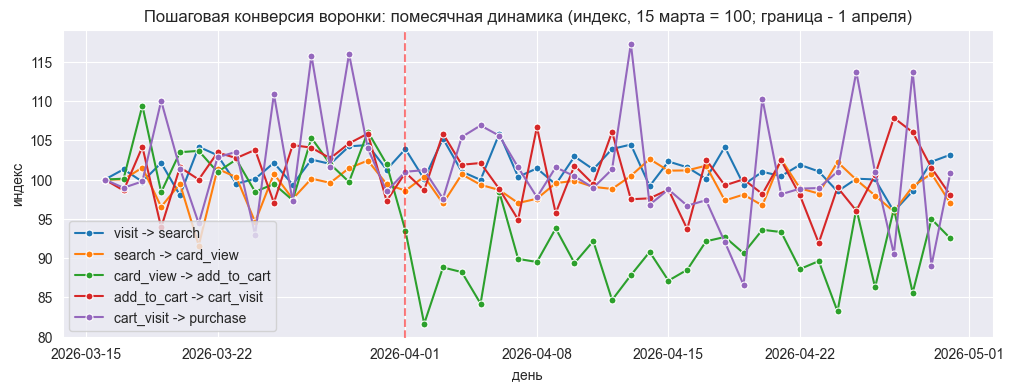

In [60]:
reach = funnel.groupby("session_date")[funnel_steps].mean()
reach = reach[reach.index > "03-15-26"]

# построение пошаговой конверсии
step_cr = reach.copy()
for i in range(len(funnel_steps) - 1, 0, -1):
    step_cr[funnel_steps[i]] = reach[funnel_steps[i]] / reach[funnel_steps[i - 1]]
step_cr = step_cr.drop(columns="service_visit") 

step_cr.columns = [
    "visit -> search",
    "search -> card_view",
    "card_view -> add_to_cart",
    "add_to_cart -> cart_visit",
    "cart_visit -> purchase",
]

plt.figure(figsize=(12, 4))
for col in step_cr.columns:
    sns.lineplot(normalize(step_cr[col]), marker="o", markersize=5, label=col)
plt.axvline(pd.Timestamp("2026-04-01"), ls="--", color="red", alpha=0.5)

plt.title("Пошаговая конверсия воронки: помесячная динамика (индекс, 15 марта = 100; граница - 1 апреля)")
plt.ylabel("индекс")
plt.xlabel("день")
plt.legend(loc="lower left")

plt.show()

Слом произошел в начале апреля почти мгновенно. Это дает основание полагать, что падение конверсии вызвано обновлением или чем-то подобным. Посмотрим, есть ли разница в конверсиях по платформам: 


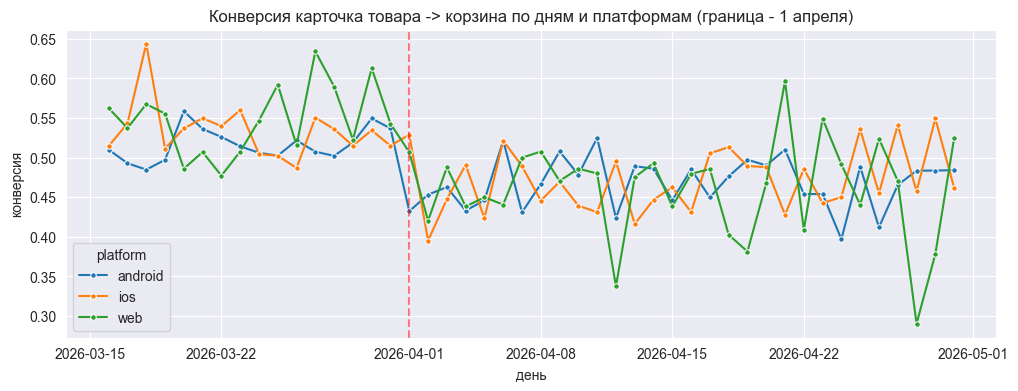

In [61]:
reach = funnel.groupby(["session_date","platform"])[["product_card_view","add_to_cart"]].sum()
cr = (reach["add_to_cart"] / reach["product_card_view"]).reset_index(name="cr")
cr = cr[cr["session_date"] > "2026-03-15"]

plt.figure(figsize=(12,4))

sns.lineplot(cr, x="session_date", y="cr", hue="platform", marker="o", markersize=4)
plt.axvline(pd.Timestamp("2026-04-01"), ls="--", color="red", alpha=0.5)

plt.title("Конверсия карточка товара -> корзина по дням и платформам (граница - 1 апреля)")
plt.ylabel("конверсия")
plt.xlabel("день")
plt.show()

Видим, что конверсия сильно падает на всех платформах. Чтобы окончательно убедиться, что падение конверсии клиентов из карточки товара в корзину значимо, проведем z-тест пропорций:

In [62]:
march = funnel[(funnel["session_month"]=="2026-03-01") & (funnel["product_card_view"]==1)]
april = funnel[(funnel["session_month"]=="2026-04-01") & (funnel["product_card_view"]==1)]

conversions = [march["add_to_cart"].sum(), april["add_to_cart"].sum()]
observations  = [len(march), len(april)]
z, p = proportions_ztest(conversions, observations)
print(f"CR март={conversions[0]/observations[0]:.4f}, апрель={conversions[1]/observations[1]:.4f}")
print(f"z={z:.2f}, p-value={p:.2e}")

CR март=0.5287, апрель=0.4676
z=10.36, p-value=3.75e-25


Отвергаем нулевую гипотезу о равенстве конверсий: различие конверсии "карточка товара -> корзина" между мартом и апрелем статистически значимо (z = 10.4, p $\approx$ 3.75 * 10^(-25)).

Составим таблицу, которая будет показывать размер падения конверсии из карточки товара в корзину по категориям:

In [63]:
march = funnel[funnel["session_month"]=="2026-03-01"]
april = funnel[funnel["session_month"]=="2026-04-01"]

def get_cr_delta(cat):
    rows = []
    for val in funnel[cat].dropna().unique():
        m = march[march[cat]==val]
        a = april[april[cat]==val]
        cr_m = m["add_to_cart"].sum() / m["product_card_view"].sum()
        cr_a = a["add_to_cart"].sum() / a["product_card_view"].sum()
        rows.append({
            "срез": cat, "значение": val,
            "CR март": cr_m, "CR апрель": cr_a,
            "падение, %": (cr_a / cr_m - 1) * 100,
            "вес сегмента, %": len(a) / len(april) * 100,
        })
    return pd.DataFrame(rows)

result = pd.concat([get_cr_delta(c) for c in ["platform", "city", "traffic_source", "experiment_group"]])
print(result.round(2).to_string(index=False))

            срез        значение  CR март  CR апрель  падение, %  вес сегмента, %
        platform         android     0.52       0.47      -10.40            42.44
        platform             ios     0.53       0.47      -11.65            42.29
        platform             web     0.54       0.46      -14.40            15.27
            city          Москва     0.52       0.47      -10.37            53.02
            city          Казань     0.52       0.45      -13.71             9.94
            city Санкт-Петербург     0.54       0.47      -12.65            21.82
            city    Екатеринбург     0.53       0.49       -7.10             7.37
            city     Новосибирск     0.55       0.45      -17.69             7.86
  traffic_source          direct     0.53       0.46      -12.87            34.44
  traffic_source         organic     0.53       0.47      -10.85            23.93
  traffic_source             crm     0.54       0.48      -10.91            19.86
  traffic_source

Падение конверсии product_card_view -> add_to_cart наблюдается во всех сегментах. Все крупные сегменты (с весом >15%) просели синхронно на -10...-14%; отклонения у мелких сегментов (Новосибирск, test, referral) объясняются шумом малых выборок (вес <10%). no_campaign (95% аудитории) просел на −11.6% - значит, причина системная и не связана ни с маркетингом, ни с конкретной платформой/каналом. Это указывает на общее техническое/продуктовое изменение, затронувшее всех пользователей одновременно

In [64]:
def month_agg(funnel, orders, month):
    funnel_month = funnel[funnel["session_month"] == month]
    orders_month = orders[orders["order_month"] == month]
    sessions = funnel_month["session_id"].nunique()
    purchases = funnel_month["purchase"].sum()
    cr  = purchases / sessions
    aov = orders_month["gross_merchandise_value"].mean()
    return sessions, cr, aov

sessions_march, CR_march, AOV_march = month_agg(funnel, orders, "2026-03-01")
sessions_april, CR_april, AOV_april = month_agg(funnel, orders, "2026-04-01")

GMV_march = sessions_march * CR_march * AOV_march
GMV_april = sessions_april * CR_april * AOV_april

# последовательная подстановка (порядок: сессии -> конверсия -> чек)
gmv_0 = sessions_march * CR_march * AOV_march  # начальное значение в марте
gmv_1 = sessions_april * CR_march * AOV_march  # изменение значения сессии
gmv_2 = sessions_april * CR_april * AOV_march  # изменение значения конверсии
gmv_3 = sessions_april * CR_april * AOV_april  # изменение значения среднего чека

contribution_sessions = gmv_1 - gmv_0
contribution_cr = gmv_2 - gmv_1
contribution_aov = gmv_3 - gmv_2

print(f"GMV март:  {GMV_march / 1e6 :.2f} млн")
print(f"  вклад сессий: {contribution_sessions / 1e6 :+.2f} млн")
print(f"  вклад конверсии: {contribution_cr / 1e6 :+.2f} млн")
print(f"  вклад чека: {contribution_aov / 1e6 :+.2f} млн")
print(f"GMV апрель: {GMV_april / 1e6:.2f} млн")
print(f"проверка: {(contribution_sessions + contribution_cr + contribution_aov) / 1e6 :+.2f} = {(GMV_april - GMV_march) / 1e6 :+.2f}")

GMV март:  11.23 млн
  вклад сессий: -0.80 млн
  вклад конверсии: -1.58 млн
  вклад чека: -0.35 млн
GMV апрель: 8.51 млн
проверка: -2.72 = -2.72


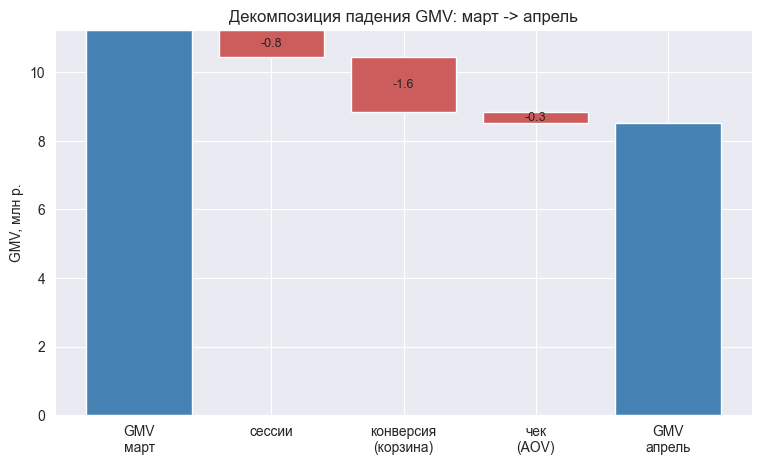

In [65]:
labels = ["GMV\nмарт", "сессии", "конверсия\n(корзина)", "чек\n(AOV)", "GMV\nапрель"]
values = [GMV_march, contribution_sessions, contribution_cr, contribution_aov, GMV_april]

fig, ax = plt.subplots(figsize=(9, 5))
cumsum = GMV_march
for i, (lab, val) in enumerate(zip(labels, values)):
    if i == 0 or i == len(labels)-1:                 # столбцы-итоги от нуля
        ax.bar(i, val / 1e6, color="steelblue")
        cumsum = val
    else:                                            # промежуточные ступеньки
        color = "indianred" if val < 0 else "seagreen"
        ax.bar(i, val / 1e6, bottom=cumsum / 1e6, color=color)
        ax.text(i, (cumsum + val / 2) / 1e6, f"{val / 1e6 :+.1f}", ha="center", va="center", fontsize=9)
        cumsum += val

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_ylabel("GMV, млн р.")
ax.set_title("Декомпозиция падения GMV: март -> апрель")

plt.show()

**Декомпозиция падения GMV (март -> апрель)**

Оборот снизился с 11.23 до 8.51 млн р. - на **2.72 млн р (-24%)**. Разложение падения по факторам методом последовательной подстановки (`GMV = число сессий × конверсия в покупку × средний чек`):

- **Конверсия в покупку: -1.58 млн р. (58% падения)** - основной и аномальный драйвер. Просадка сосредоточена на шаге "просмотр карточки товара -> добавление в корзину".
- **Число сессий: -0.80 млн р. (29%)** - вклад в значительной части **календарный**: в апреле на один день меньше, чем в марте, и меньше выходных (а в выходные сессий стабильно больше). Реальный отток пользователей минимален - MAU держится на уровне предыдущих месяцев.
- **Средний чек: -0.35 млн р. (13%)** - небольшое снижение, обусловлено падением средней цены товара, а не размера корзины (среднее число товаров в заказе стабильно).

Сумма вкладов точно равна полному падению (проверка тождества: -0.80 - 1.58 - 0.35 = -2.72 млн р).

**Главный вывод декомпозиции:** оборот упал не потому, что пришло меньше людей или они стали меньше тратить, а потому, что резко сломался конкретный шаг воронки - добавление товара в корзину.

# 3. Выводы и рекомендации

## 3.1 Что произошло

Оборот сервиса (GMV) в апреле 2026 упал на **2.72 млн р (−24%)** относительно марта. Последовательная декомпозиция метрики позволила локализовать причину:

1. **GMV = число заказов × средний чек.** Падение обусловлено в первую очередь **числом заказов**; средний чек просел слабо и за счёт снижения цены товара, а не размера корзины - число товаров в заказе стабильно.

2. **Число заказов = число покупателей × частота.** Число активных пользователей (MAU) осталось на уровне предыдущих месяцев - оттока аудитории нет. Падение заказов вызвано снижением **конверсии** пользователя в покупателя.

3. **Конверсия в покупку = произведение конверсий шагов воронки.** Из пяти переходов воронки четыре стабильны весь период. Просадка сосредоточена ровно на одном шаге: **"просмотр карточки товара -> добавление в корзину"** (конверсия упала примерно с 0.53 до 0.47, −11.6%).

## 3.2 Характер и причина слома

- **Резкость.** На подневной динамике видно, что конверсия product_card_view -> add_to_cart обрушилась **скачком 1 апреля** и осталась на новом уровне весь месяц. Это не плавная деградация (что указывало бы на цены, ассортимент или качество трафика), а одномоментный слом - типичная сигнатура технического/продуктового изменения (релиз).

- **Системность.** Падение статистически значимо (z-тест пропорций: z = 10.4, p $\approx$ 4 * 10^(-25)) и наблюдается во **всех сегментах** примерно в равной степени: все крупные сегменты (вес >15%) просели на -10...-14%, слом синхронен по всем платформам (Android, iOS, Web). Отклонения мелких сегментов (Новосибирск, test, referral) объясняются шумом малых выборок.

- **Не маркетинг.** Группа `no_campaign`, не получающая коммуникаций и составляющая **95% аудитории**, просела ровно на системные −11.6%. Это позволяет исключить маркетинговый эксперимент и отдельные каналы как причину. Таблица коммуникаций и группы test/control для объяснения падения оборота нерелевантны.

**Вывод:** причина падения оборота - техническое или продуктовое изменение в механике добавления товара в корзину, выкаченное около 1 апреля 2026 года и одинаково затронувшее всех пользователей.

## 3.3 Рекомендации

1. **Найти и устранить причину на шаге добавления в корзину.** Проверить все релизы, A/B-эксперименты и изменения UI/бэкенда, выкаченные около 1 апреля и затрагивающие кнопку или механику "добавить в корзину" (изменение интерфейса, ошибка, замедление отклика, проблема с наличием товара). При подтверждении - откатить или исправить.

2. **Настроить мониторинг воронки.** Добавить предупреждения на пошаговую конверсию каждого этапа: текущий слом длился весь месяц, прежде чем был замечен по обороту. Контроль на уровне шагов воронки позволил бы поймать проблему за день, а не за месяц.

Восстановление конверсии до мартовского уровня возвращает $\approx$1.6 млн р оборота в месяц - это основной резерв.